# 🧠 PINN Practice Notebook — Write Everything from Scratch

**Guided blank-slate practice covering all 12 notebooks in the Physics AI Series.**

---

> **How to use this notebook:**
> - Read each cell's comments carefully — they tell you exactly what to write, line by line.
> - Write your own code to fill every `# YOUR CODE HERE` gap.
> - Run each cell before moving to the next.
> - If you get stuck, refer to the reference notebook listed at the top of each section.
> - Do not copy-paste from the reference notebooks — the goal is to build muscle memory.

---

## Series Map

| # | Notebook | Level | Physics |
|---|----------|-------|---------|
| 01 | Intro to PINNs | 🟢 Beginner | First-order ODE: $dy/dx = -y$ |
| 02 | Second-Order ODEs | 🟢 Beginner | Damped oscillator: $m\ddot{x}+c\dot{x}+kx=0$ |
| 03 | Heat Equation | 🟡 Intermediate | 1-D diffusion: $u_t = \alpha u_{xx}$ |
| 04 | Burgers Equation | 🟡 Intermediate | Nonlinear PDE: $u_t + uu_x = \nu u_{xx}$ |
| 05 | Reaction Kinetics | 🟡 Intermediate | $A \to B \to C$ system |
| 06 | Wave Equation | 🟡 Intermediate | $u_{tt} = c^2 u_{xx}$ |
| 07 | Inverse Parameter Estimation | 🔴 Advanced | Learn unknown $k$ from data |
| 08 | Adaptive Sampling | 🔴 Advanced | Residual-based collocation |
| 09 | DeepONet | 🔴 Advanced | Operator learning |
| 10 | Navier-Stokes | 🟣 Research | 2-D incompressible flow |
| 11 | Physics-Informed DeepONet | 🟣 Research | PI-DeepONet |
| 12 | Architectures & Training | 🟣 Research | Fourier features, adaptive weighting |

---

## Table of Contents
1. [Setup & Shared Utilities](#setup)
2. [NB-01 · First-Order ODE](#nb01)
3. [NB-02 · Second-Order ODE — Damped Oscillator](#nb02)
4. [NB-03 · 1-D Heat Equation](#nb03)
5. [NB-04 · Burgers Equation](#nb04)
6. [NB-05 · Reaction Kinetics A→B→C](#nb05)
7. [NB-06 · Wave Equation](#nb06)
8. [NB-07 · Inverse Parameter Estimation](#nb07)
9. [NB-08 · Adaptive Collocation Sampling](#nb08)
10. [NB-09 · DeepONet — Operator Learning](#nb09)
11. [NB-10 · Navier-Stokes Flow](#nb10)
12. [NB-11 · Physics-Informed DeepONet](#nb11)
13. [NB-12 · Architectures & Training Strategies](#nb12)

---
<a id='setup'></a>
## ⚙️ Setup & Shared Utilities

Write the shared imports and helper functions used throughout all 12 exercises.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
# Import: torch, torch.nn as nn, numpy as np, matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds: torch.manual_seed(42) and np.random.seed(42)
torch.manual_seed(42)

# Detect device: use 'cuda' if available, else 'cpu'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Print torch version and device
print(f"Torch version: {torch.__version__}")

Device: cpu
Torch version: 2.13.0


In [3]:
# ── Shared helper: make_pinn(layer_sizes) ─────────────────────────────────────
# Build a fully-connected network from a list of layer sizes.
# Activation: nn.Tanh() between every pair of layers (not after the last).
# Initialise every Linear layer with Xavier normal weights and zero bias.
# Move the network to 'device' and return it.

def make_pinn(layer_sizes):
    # Build a list of alternating Linear + Tanh layers
    layers = []
    for i in range(len(layer_sizes)-1):
        layers.append(nn.Linear(layer_sizes[i],layer_sizes[i+1]))
        if i<len(layer_sizes)-2:
            layers.append(nn.Tanh())

    # Apply Xavier normal init and zero bias to every Linear layer
    for layer in layers:
        if isinstance(layer, nn.Linear):
            nn.init.xavier_normal_(layer.weight)
            nn.init.zeros_(layer.bias)

    # Wrap in nn.Sequential, move to device, return
    return nn.Sequential(*layers).to(device)

model=make_pinn([1, 20, 20, 1])
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Tanh()
  (2): Linear(in_features=20, out_features=20, bias=True)
  (3): Tanh()
  (4): Linear(in_features=20, out_features=1, bias=True)
)


In [4]:
# ── Shared helper: grad(y, x) ────────────────────────────────────────────────
# Compute dy/dx using torch.autograd.grad.
# Use grad_outputs=torch.ones_like(y) and create_graph=True.
# Return only [0] (the gradient tensor, not the tuple).

def grad(y, x):
    return torch.autograd.grad(y, 
                               x, 
                               grad_outputs=torch.ones_like(y), 
                               create_graph=True)[0]

In [12]:
# ── Shared helper: train(model, optimizer, loss_fn, n_epochs) ─────────────────
# Generic training loop.
# loss_fn() should return (total_loss, *component_losses).
# Each epoch: zero grad → call loss_fn() → backward → step.
# Print every 'print_every' epochs (default 500).
# Append total loss to a list and return it.

def train(model, optimizer, loss_fn, n_epochs, print_every=500):
    history = []
    for epoch in range(n_epochs):
        # Zero gradients
        optimizer.zero_grad()

        # Call loss_fn(), unpack result
        total_loss, *component_losses = loss_fn()

        # Backward pass and optimizer step
        total_loss.backward()
        optimizer.step()

        # Append total loss to history
        history.append(total_loss.item())

        # Print if epoch % print_every == 0
        if epoch%print_every == 0:
            print(f"Epoch {epoch}: Total Loss = {total_loss.item():.6f}")

    return history

print('Shared utilities defined ✓')

Shared utilities defined ✓


---
<a id='nb01'></a>
## 📗 NB-01 · First-Order ODE
**Reference:** `01_Beginner/01_intro_to_pinn.ipynb`

**Problem:** $\dfrac{dy}{dx} = -y,\quad y(0)=1,\quad x\in[0,5]$ &nbsp;&nbsp; → &nbsp;&nbsp; Analytical: $y(x) = e^{-x}$

**Steps:**
1. Build a PINN `[1 → 32 → 32 → 32 → 1]`
2. Create 1000 collocation points on $[0,5]$ with `requires_grad=True`
3. Define `ode_residual_01(model, x)` → returns $r = dy/dx + y$
4. Define `loss_fn_01()` → physics loss + BC loss
5. Train 5 000 epochs with Adam lr=1e-3
6. Plot: PINN vs analytical | training loss curves
7. **Bonus:** repeat with 10 noisy observations added as a data loss

In [13]:
# ── NB-01 Step 1: Build the PINN ──────────────────────────────────────────────
torch.manual_seed(42)

# Call make_pinn with architecture [1, 32, 32, 32, 1]
model_01 = make_pinn([1, 32, 32, 32, 1])

# Print the model and its total parameter count
print(model_01)
print(f"Total parameters: {sum(p.numel() for p in model_01.parameters())}")

Sequential(
  (0): Linear(in_features=1, out_features=32, bias=True)
  (1): Tanh()
  (2): Linear(in_features=32, out_features=32, bias=True)
  (3): Tanh()
  (4): Linear(in_features=32, out_features=32, bias=True)
  (5): Tanh()
  (6): Linear(in_features=32, out_features=1, bias=True)
)
Total parameters: 2209


In [14]:
# ── NB-01 Step 2: Collocation & boundary points ───────────────────────────────

# Create 1000 evenly-spaced points on [0, 5], shape (-1,1), on device
# Set requires_grad_(True) so we can differentiate w.r.t. x
N_collocation = 1000
x_col_01 = torch.linspace(0, 5, N_collocation, device=device).view(-1,1)
x_col_01.requires_grad_(True)

# Boundary point: x_bc = tensor([[0.0]]) on device
x_bc_01 = torch.tensor([[0.0]], device=device) # x= 0

# Boundary value: y_bc = tensor([[1.0]]) on device
y_bc_01 = torch.tensor([[1.0]], device=device) # y(0) = 1

In [15]:
# ── NB-01 Step 3: ODE residual ────────────────────────────────────────────────

def ode_residual_01(model, x):
    # Forward pass: y = model(x)
    y = model(x)

    # Compute dy/dx using the shared grad() helper
    dy_dx = grad(y,x)

    # Return residual: dy_dx + y  (should equal 0 for exact solution)
    return dy_dx + y

In [17]:
# ── NB-01 Step 4 & 5: Loss function + Train ───────────────────────────────────

# Create Adam optimizer for model_01 with lr=1e-3
opt_01 = torch.optim.Adam(model_01.parameters(), lr=1e-3)

def loss_fn_01():
    # Compute ODE residual at collocation points
    residual = ode_residual_01(model_01, x_col_01)

    # Physics loss: mean of squared residuals
    loss_physics = torch.mean(residual**2)

    # BC loss: mean squared error between model(x_bc_01) and y_bc_01
    loss_bc = torch.mean((model_01(x_bc_01)-y_bc_01)**2)

    # Return total, physics, bc (so train() can print components)
    return loss_physics + loss_bc, loss_physics, loss_bc

# Call train() for 5000 epochs, store result in hist_01
hist_01 = train(model_01, opt_01, loss_fn_01, n_epochs=5000)

Epoch 0: Total Loss = 1.696023
Epoch 500: Total Loss = 0.000371
Epoch 1000: Total Loss = 0.000090
Epoch 1500: Total Loss = 0.000050
Epoch 2000: Total Loss = 0.000032
Epoch 2500: Total Loss = 0.000022
Epoch 3000: Total Loss = 0.000014
Epoch 3500: Total Loss = 0.000008
Epoch 4000: Total Loss = 0.000004
Epoch 4500: Total Loss = 0.000002


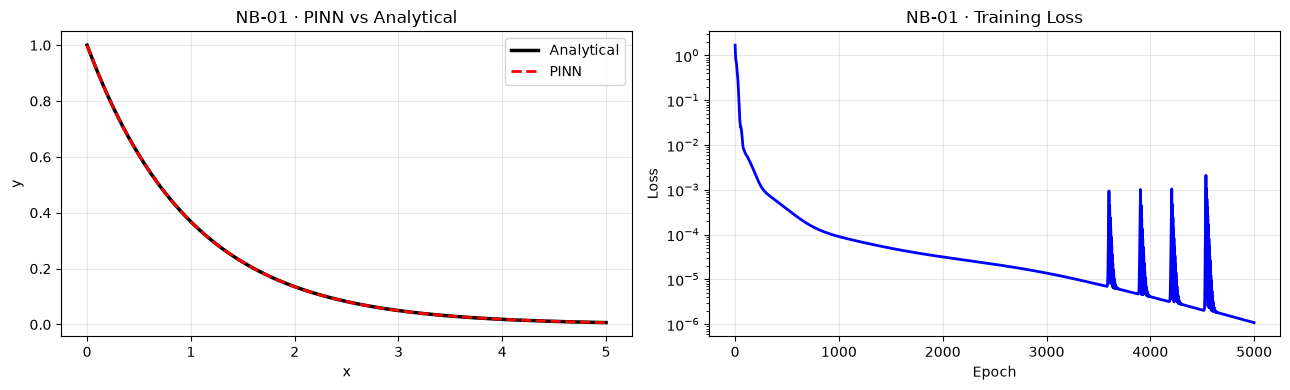

Max absolute error: 0.000321
Mean absolute error: 0.000167


In [18]:
# ── NB-01 Step 6: Plot results ────────────────────────────────────────────────

# Set model to eval mode
model_01.eval()

# Create 500 test points on [0,5] and predict (use torch.no_grad())
x_test_01 = torch.linspace(0, 5, 500, device=device).view(-1,1)
with torch.no_grad():
    y_pred_01 = model_01(x_test_01)

# Convert to numpy; compute analytical solution y = exp(-x)
x_np_01   = x_test_01.cpu().numpy()
y_true_01 = np.exp(-x_np_01)

# 1x2 subplot figure (figsize 13x4)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: analytical (black solid, lw=2.5) vs PINN (red dashed, lw=2)
# Labels: x='x', y='y'; title='NB-01 · PINN vs Analytical'; legend; grid alpha=0.3
axes[0].plot(x_np_01, y_true_01, 'k-', lw=2.5, label='Analytical')
axes[0].plot(x_np_01, y_pred_01.cpu().numpy(), 'r--', lw=2, label='PINN')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('NB-01 · PINN vs Analytical')
axes[0].legend()
axes[0].grid(alpha=0.3)



# Right: semilogy of hist_01 (blue solid); xlabel='Epoch', ylabel='Loss'; title; grid
axes[1].semilogy(hist_01, 'b-', lw=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('NB-01 · Training Loss')
axes[1].grid(alpha=0.3)



plt.tight_layout()
plt.savefig('nb01_ode.png', dpi=150, bbox_inches='tight')
plt.show()

# Print max and mean absolute error
abs_error = np.abs(y_pred_01.cpu().numpy() - y_true_01)
print(f"Max absolute error: {abs_error.max():.6f}")
print(f"Mean absolute error: {abs_error.mean():.6f}")

Epoch 0: Total Loss = 1.272645
Epoch 500: Total Loss = 0.000965
Epoch 1000: Total Loss = 0.000803
Epoch 1500: Total Loss = 0.000786
Epoch 2000: Total Loss = 0.000781
Epoch 2500: Total Loss = 0.000777
Epoch 3000: Total Loss = 0.000816
Epoch 3500: Total Loss = 0.000772
Epoch 4000: Total Loss = 0.000770
Epoch 4500: Total Loss = 0.000769


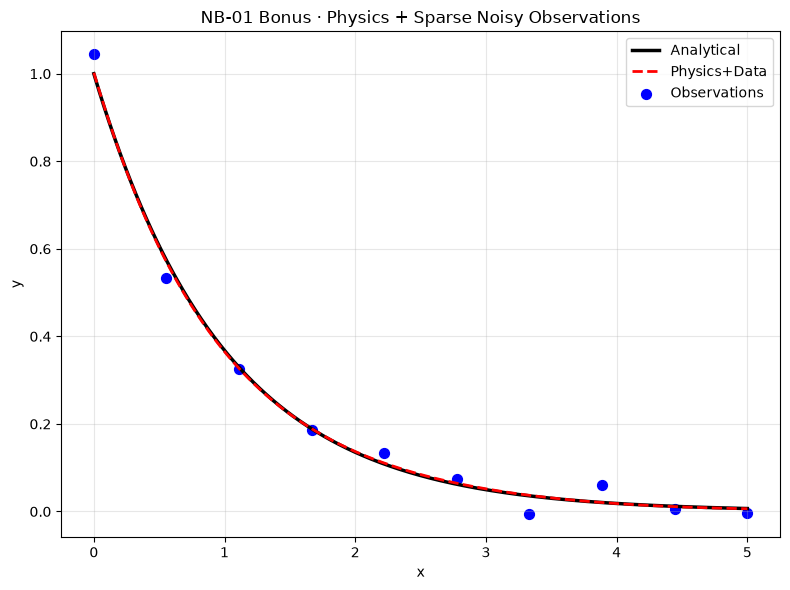

In [22]:
# ── NB-01 Bonus: Physics + sparse noisy observations ─────────────────────────
torch.manual_seed(0)

# Build a second model model_01b ([1,32,32,32,1]) and optimizer opt_01b
model_01b = make_pinn([1, 32, 32, 32, 1])
opt_01b = torch.optim.Adam(model_01b.parameters(), lr=1e-3)


# 10 noisy observations: x_obs_np = linspace(0,5,10)
#                        y_obs_np = exp(-x_obs_np) + 0.02*randn(10)
# Convert both to float32 tensors shape (-1,1) on device
# YOUR CODE HERE
x_obs_np = np.linspace(0, 5, 10)
y_obs_np = np.exp(-x_obs_np) + 0.02 * np.random.randn(10)
x_obs_01b = torch.tensor(x_obs_np, dtype=torch.float32, device=device).view(-1, 1)
y_obs_01b = torch.tensor(y_obs_np, dtype=torch.float32, device=device).view(-1, 1)



# loss_fn_01b(): physics loss + BC loss + data loss (MSE on observations)
def loss_fn_01b():
    # Compute ODE residual at collocation points
    residual = ode_residual_01(model_01b, x_col_01)

    # Physics loss: mean of squared residuals
    loss_physics = torch.mean(residual**2)

    # BC loss: mean squared error between model(x_bc_01) and y_bc_01
    loss_bc = torch.mean((model_01b(x_bc_01)-y_bc_01)**2)

    # Data loss: mean squared error on observations
    loss_data = torch.mean((model_01b(x_obs_01b)-y_obs_01b)**2)

    # Return total, physics, bc, data (so train() can print components)
    return loss_physics + loss_bc + loss_data, loss_physics, loss_bc, loss_data




# Train 5000 epochs
hist_01b = train(model_01b, opt_01b, loss_fn_01b, n_epochs=5000)


# Plot: analytical / physics-only / physics+data on one axes; scatter observations
# Set model to eval mode
model_01b.eval()

# Create 500 test points on [0,5] and predict (use torch.no_grad())
x_test_01b = torch.linspace(0, 5, 500, device=device).view(-1,1)
with torch.no_grad():
    y_pred_01b = model_01b(x_test_01b)

# Convert to numpy; compute analytical solution y = exp(-x)
x_np_01b   = x_test_01b.cpu().numpy()
y_true_01b = np.exp(-x_np_01b)

# Plot
plt.figure(figsize=(8,6))
plt.plot(x_np_01b, y_true_01b, 'k-', lw=2.5, label='Analytical')
plt.plot(x_np_01b, y_pred_01b.cpu().numpy(), 'r--', lw=2, label='Physics+Data')
plt.scatter(x_obs_np, y_obs_np, c='b', s=50, label='Observations')
plt.xlabel('x')
plt.ylabel('y')
plt.title('NB-01 Bonus · Physics + Sparse Noisy Observations')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 🏋️ NB-01 Exercises

1. **Extend the domain:** Change the domain to `x ∈ [0, 10]`. How many collocation points and epochs do you need to maintain the same accuracy? Plot the absolute error across the extended domain.

2. **Different ODE:** Replace `dy/dx = -y` with `dy/dx = -2y + sin(x)`. The analytical solution is `y(x) = (e^{-2x}(2·sin(0)+cos(0)) + 2·sin(x) - cos(x)) / 5` — derive it, implement the new residual, and verify the PINN matches.

3. **Change the activation function:** Swap `nn.Tanh` for `nn.SiLU` (Swish) in `make_pinn`. Compare loss curves and final accuracy. Which converges faster?

4. **Vary collocation density:** Run 3 experiments with `N_col = 50, 200, 1000`. Plot max absolute error vs. `N_col`. At what point does adding more collocation points stop helping?

5. **Finite difference comparison:** Solve the same ODE numerically using Euler's method with 100 steps. Compare the error of Euler vs PINN as a function of computational budget (number of evaluations).

> 💡 **Reminder:** the PINN recipe you built here — `requires_grad → forward → residual → loss → backward` — is identical for every problem in this series.

Epoch 0: Total Loss = 2.418631
Epoch 500: Total Loss = 0.000293
Epoch 1000: Total Loss = 0.000092
Epoch 1500: Total Loss = 0.000041
Epoch 2000: Total Loss = 0.000026
Epoch 2500: Total Loss = 0.000019
Epoch 3000: Total Loss = 0.000014
Epoch 3500: Total Loss = 0.000011
Epoch 4000: Total Loss = 0.000008
Epoch 4500: Total Loss = 0.000005
Epoch 5000: Total Loss = 0.000016
Epoch 5500: Total Loss = 0.000003
Epoch 6000: Total Loss = 0.000002
Epoch 6500: Total Loss = 0.000002
Epoch 7000: Total Loss = 0.000067
Epoch 7500: Total Loss = 0.000001
Epoch 8000: Total Loss = 0.000453
Epoch 8500: Total Loss = 0.000001
Epoch 9000: Total Loss = 0.000001
Epoch 9500: Total Loss = 0.000000


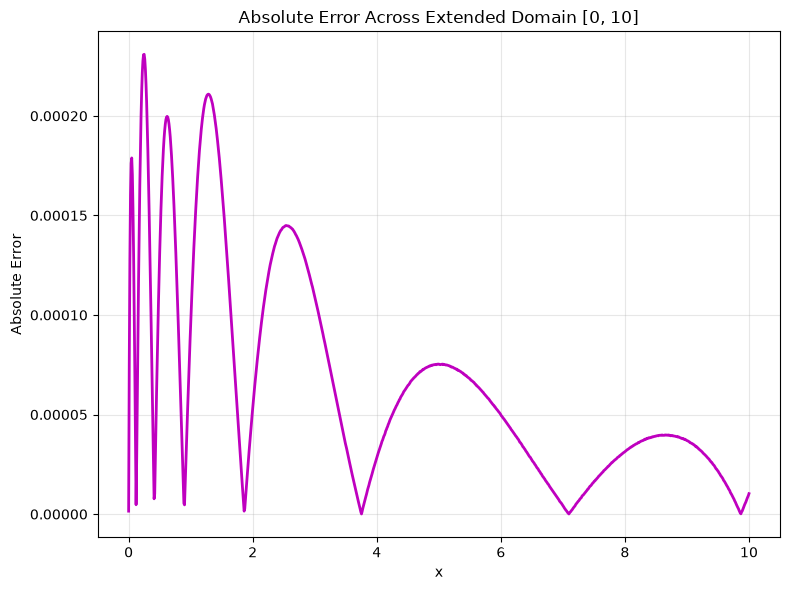

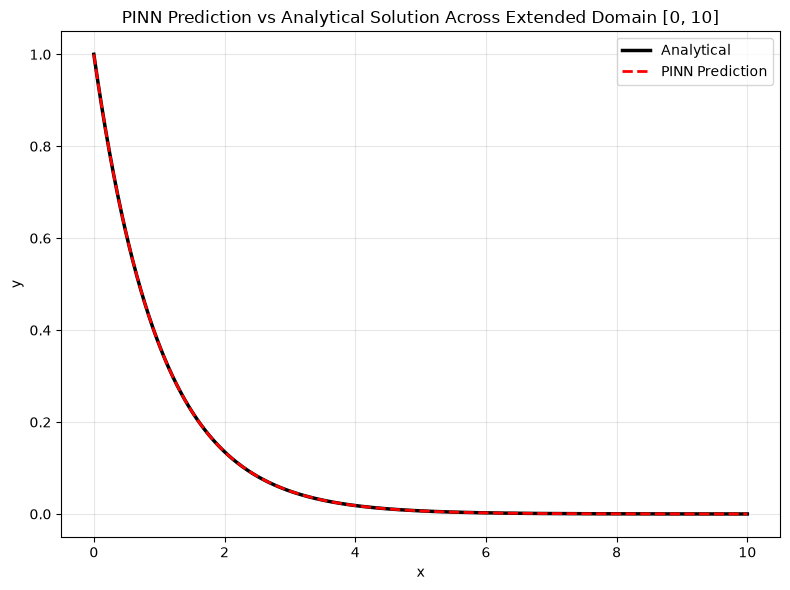

In [24]:
# Extend the domain: Change the domain to x ∈ [0, 10]. 
# How many collocation points and epochs do you need 
# to maintain the same accuracy? 
# Plot the absolute error across the extended domain.

model_01_ext = make_pinn([1, 32, 32, 32, 1])
opt_01_ext = torch.optim.Adam(model_01_ext.parameters(), lr=1e-3)

N_coollocation_ext = 2000
x_col_ext = torch.linspace(0, 10, N_coollocation_ext, device=device).view(-1,1)
x_col_ext.requires_grad_(True)

# BC is unchanged: y(0) = 1
x_bc_ext = torch.tensor([[0.0]], device=device)
y_bc_ext = torch.tensor([[1.0]], device=device)

def loss_fn_01_ext():
    residual = ode_residual_01(model_01_ext, x_col_ext)
    loss_physics = torch.mean(residual**2)
    loss_bc = torch.mean((model_01_ext(x_bc_ext)-y_bc_ext)**2)
    return loss_physics + loss_bc, loss_physics, loss_bc

hist_01_ext = train(model_01_ext, opt_01_ext, loss_fn_01_ext, n_epochs=10000)

model_01_ext.eval()
x_test_ext = torch.linspace(0, 10, 1000, device=device).view(-1,1)
with torch.no_grad():
    y_pred_ext = model_01_ext(x_test_ext)

x_np_ext = x_test_ext.cpu().numpy()
y_true_ext = np.exp(-x_np_ext)
y_pred_ext = y_pred_ext.cpu().numpy()

# Plot absolute error across the extended domain
abs_error_ext = np.abs(y_pred_ext - y_true_ext)
plt.figure(figsize=(8,6))
plt.plot(x_np_ext, abs_error_ext, 'm-', lw=2)
plt.xlabel('x')
plt.ylabel('Absolute Error')
plt.title('Absolute Error Across Extended Domain [0, 10]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Plot the the pred vs true values across the extended domain
plt.figure(figsize=(8,6))
plt.plot(x_np_ext, y_true_ext, 'k-', lw=2.5, label='Analytical')
plt.plot(x_np_ext, y_pred_ext, 'r--', lw=2, label='PINN Prediction')
plt.xlabel('x')
plt.ylabel('y')
plt.title('PINN Prediction vs Analytical Solution Across Extended Domain [0, 10]')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


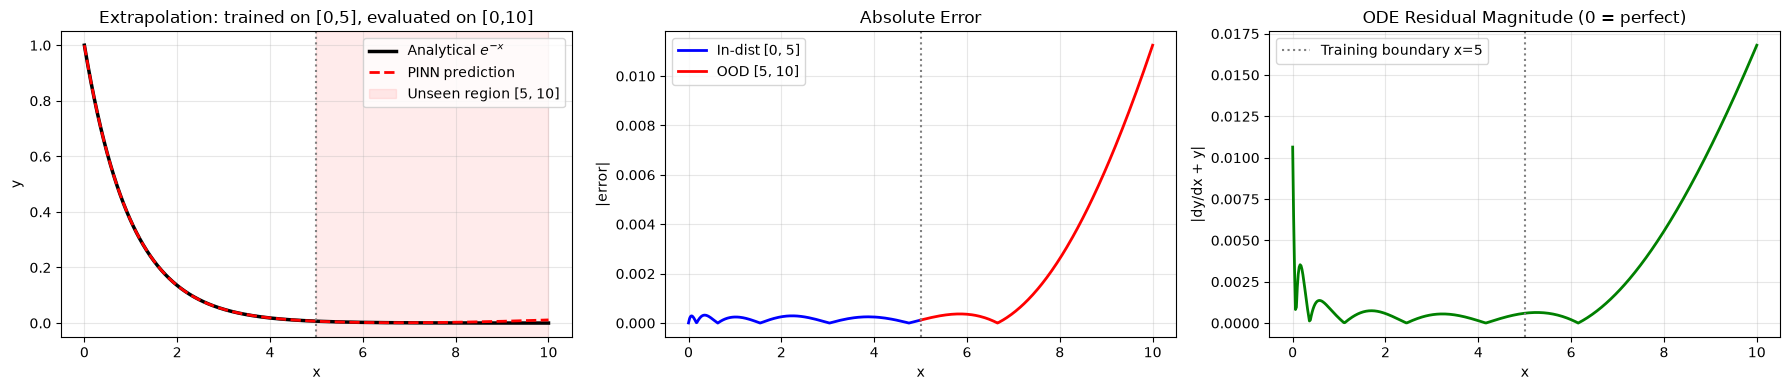

In-distribution  [0,5]  — max error: 0.000321
Out-of-dist      [5,10] — max error: 0.011246

ODE residual  [0,5]  — mean |r|: 0.000633
ODE residual  [5,10] — mean |r|: 0.005314


In [25]:
# ── Extrapolation Test: model trained on [0,5], evaluated on [0,10] ──────────
# model_01 was trained ONLY with collocation points on [0, 5].
# Now we ask: does it still satisfy dy/dx = -y on [6, 10]?

model_01.eval()

x_extrap = torch.linspace(0, 10, 1000, device=device).view(-1, 1)
with torch.no_grad():
    y_extrap = model_01(x_extrap).cpu().numpy()

x_np_extrap = x_extrap.cpu().numpy()
y_true_extrap = np.exp(-x_np_extrap)
abs_err_extrap = np.abs(y_extrap - y_true_extrap)

# Split indices: in-distribution [0,5] vs out-of-distribution [5,10]
in_mask  = x_np_extrap.flatten() <= 5.0
out_mask = x_np_extrap.flatten() > 5.0

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Left: solution ────────────────────────────────────────────────────────────
axes[0].plot(x_np_extrap, y_true_extrap, 'k-', lw=2.5, label='Analytical $e^{-x}$')
axes[0].plot(x_np_extrap, y_extrap,      'r--', lw=2,   label='PINN prediction')
axes[0].axvspan(5, 10, alpha=0.08, color='red', label='Unseen region [5, 10]')
axes[0].axvline(5, color='gray', ls=':', lw=1.5)
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')
axes[0].set_title('Extrapolation: trained on [0,5], evaluated on [0,10]')
axes[0].legend(); axes[0].grid(alpha=0.3)

# ── Middle: absolute error split by region ────────────────────────────────────
axes[1].plot(x_np_extrap[in_mask],  abs_err_extrap[in_mask],  'b-', lw=2, label='In-dist [0, 5]')
axes[1].plot(x_np_extrap[out_mask], abs_err_extrap[out_mask], 'r-', lw=2, label='OOD [5, 10]')
axes[1].axvline(5, color='gray', ls=':', lw=1.5)
axes[1].set_xlabel('x'); axes[1].set_ylabel('|error|')
axes[1].set_title('Absolute Error')
axes[1].legend(); axes[1].grid(alpha=0.3)

# ── Right: ODE residual check — does the physics still hold? ─────────────────
# Re-run with requires_grad to compute the residual outside [0, 5]
x_check = torch.linspace(0, 10, 500, device=device).view(-1, 1)
x_check.requires_grad_(True)
residual_check = ode_residual_01(model_01, x_check)
res_np = residual_check.detach().cpu().numpy()
x_check_np = x_check.detach().cpu().numpy()

axes[2].plot(x_check_np, np.abs(res_np), 'g-', lw=2)
axes[2].axvline(5, color='gray', ls=':', lw=1.5, label='Training boundary x=5')
axes[2].set_xlabel('x'); axes[2].set_ylabel('|dy/dx + y|')
axes[2].set_title('ODE Residual Magnitude (0 = perfect)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
print(f"In-distribution  [0,5]  — max error: {abs_err_extrap[in_mask].max():.6f}")
print(f"Out-of-dist      [5,10] — max error: {abs_err_extrap[out_mask].max():.6f}")
print(f"\nODE residual  [0,5]  — mean |r|: {np.abs(res_np[x_check_np.flatten() <= 5]).mean():.6f}")
print(f"ODE residual  [5,10] — mean |r|: {np.abs(res_np[x_check_np.flatten() > 5]).mean():.6f}")

---
<a id='nb02'></a>
## 📗 NB-02 · Second-Order ODE — Damped Oscillator
**Reference:** `01_Beginner/02_second_order_odes.ipynb`

**Problem:** $m\ddot{x}+c\dot{x}+kx=0,\quad x(0)=1,\ \dot{x}(0)=0,\quad t\in[0,10]$

Parameters: $m=1,\ c=0.4,\ k=4$ (under-damped).

**Key difference from NB-01:** you need **two** autograd passes to get $\ddot{x}$:
`dx_dt = grad(x, t)` then `d2x = grad(dx_dt, t)`

**Steps:** Build `[1→64→64→64→1]` · Two IC losses · 8 000 epochs · Plot displacement + phase portrait

In [29]:
# ── NB-02 Setup ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
m, c, k = 1.0, 0.4, 4.0

# 2000 collocation points on [0, 10]; requires_grad=True
N_collocation_02 = 2000
# Assuming you want it on the same device as your model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
t_col_02 = torch.linspace(0, 10, N_collocation_02, requires_grad=True, device=device).view(-1, 1)
# YOUR CODE HERE  (requires_grad)

# IC point: single tensor [[0.0]] on device; requires_grad=True
t_ic_02 = torch.tensor([[0.0]], device=device)
t_ic_02.requires_grad_(True)

# Build model_02 [1→64→64→64→1] and Adam optimizer lr=1e-3
model_02 = make_pinn([1, 64, 64, 64, 1])
opt_02   = torch.optim.Adam(model_02.parameters(), lr=1e-3)

In [30]:
# ── NB-02 Loss & Training ────────────────────────────────────────────────────

def loss_fn_02():
    # Forward pass: x = model_02(t_col_02)
    x = model_02(t_col_02)

    # First derivative dx/dt via grad()
    dx_dt = grad(x,t_col_02)

    # Second derivative d2x/dt2 via grad() applied to dx_dt
    dx2_dt = grad(dx_dt, t_col_02)

    # ODE residual: m*d2x + c*dx_dt + k*x
    r = m*dx2_dt + c*dx_dt + k*x

    # Physics loss: mean(r**2)
    l_phy = torch.mean(r**2)

    # IC value loss: (x(0) - 1.0)**2
    x0 = model_02(t_ic_02)
    l_ic_val = (x0 - 1.0)**2

    # IC velocity loss: (dx/dt at t=0) should equal 0
    # Use torch.autograd.grad(x0, t_ic_02, ..., create_graph=True)[0]
    dx0 = torch.autograd.grad(x0, t_ic_02, create_graph=True)[0]
    l_ic_vel = dx0**2

    l_ic = l_ic_val + l_ic_vel
    return l_phy + l_ic, l_phy, l_ic

# Train for 8000 epochs
hist_02 = train(model_02, opt_02, loss_fn_02, n_epochs=8000)

Epoch 0: Total Loss = 15.995284
Epoch 500: Total Loss = 0.222081
Epoch 1000: Total Loss = 0.102003
Epoch 1500: Total Loss = 0.060588
Epoch 2000: Total Loss = 0.040599
Epoch 2500: Total Loss = 0.027887
Epoch 3000: Total Loss = 0.022302
Epoch 3500: Total Loss = 0.020034
Epoch 4000: Total Loss = 0.017806
Epoch 4500: Total Loss = 0.015720
Epoch 5000: Total Loss = 0.012325
Epoch 5500: Total Loss = 0.010558
Epoch 6000: Total Loss = 0.008432
Epoch 6500: Total Loss = 0.005793
Epoch 7000: Total Loss = 0.003185
Epoch 7500: Total Loss = 0.002398


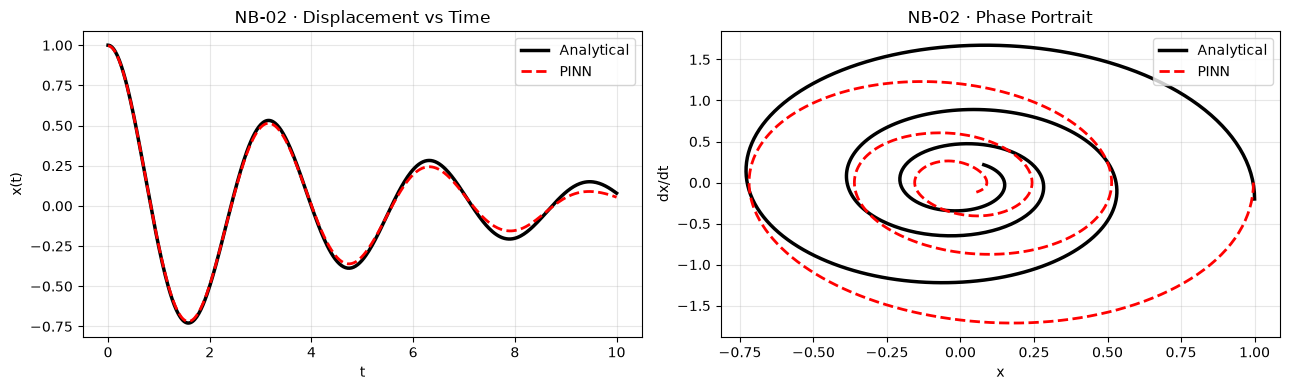

In [31]:
# ── NB-02 Plot: displacement + phase portrait ─────────────────────────────────

# Analytical solution (provided)
omega_n = np.sqrt(k/m);  zeta = c/(2*np.sqrt(m*k));  omega_d = omega_n*np.sqrt(1-zeta**2)
t_np_02 = np.linspace(0, 10, 500)
x_analytical = np.exp(-zeta*omega_n*t_np_02) * (
    np.cos(omega_d*t_np_02) + (zeta*omega_n/omega_d)*np.sin(omega_d*t_np_02)
)

model_02.eval()
t_test_02 = torch.linspace(0, 10, 500, device=device).view(-1,1)
t_test_02.requires_grad_(True)

# Forward + compute dx/dt for phase portrait
x_test_02 = model_02(t_test_02)
dx_dt_test_02 = grad(x_test_02, t_test_02)



# Detach and convert both x and dx/dt to numpy
x_test_np_02 = x_test_02.detach().cpu().numpy()
dx_dt_np_02 = dx_dt_test_02.detach().cpu().numpy()

# 1x2 figure:
#   Left:  t vs x — analytical (black) vs PINN (red dashed); labels 't','x(t)'
#   Right: x vs dx/dt phase portrait — analytical vs PINN; labels 'x','dx/dt'; title 'Phase Portrait'
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x_analytical = np.exp(-zeta*omega_n*t_np_02) * (
    np.cos(omega_d*t_np_02) + (zeta*omega_n/omega_d)*np.sin(omega_d*t_np_02)
)
# Left plot: t vs x
axes[0].plot(t_np_02, x_analytical, 'k-', lw=2.5, label='Analytical')
axes[0].plot(t_np_02, x_test_np_02, 'r--', lw=2, label='PINN')
axes[0].set_xlabel('t'); axes[0].set_ylabel('x(t)')
axes[0].set_title('NB-02 · Displacement vs Time')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right plot: x vs dx/dt phase portrait
axes[1].plot(x_analytical, -zeta*omega_n*x_analytical + omega_d*np.sqrt(1-zeta**2)*np.exp(-zeta*omega_n*t_np_02)*np.sin(omega_d*t_np_02), 'k-', lw=2.5, label='Analytical')
axes[1].plot(x_test_np_02, dx_dt_np_02, 'r--', lw=2, label='PINN')
axes[1].set_xlabel('x'); axes[1].set_ylabel('dx/dt')
axes[1].set_title('NB-02 · Phase Portrait')
axes[1].legend(); axes[1].grid(alpha=0.3)       


plt.tight_layout()
plt.savefig('nb02_oscillator.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-02 Exercise: Stiffness & High Frequency

Set `k = 144.0` (so `omega0 = 12.0`) and re-run your damped oscillator PINN. You will see the training loss plateau and the fit degrade in the later part of `[0,10]`. This is the well-known **spectral bias** — neural networks learn low frequencies before high frequencies.

**Fixes to try (each is a mini-project):**

1. **Wider/deeper network:** increase to `[1→128→128→128→128→1]` and increase `N_col` to 5 000. Does accuracy improve and at what cost?

2. **Fourier feature embedding:** map the input `t` through `[sin(2π·B·t), cos(2π·B·t)]` with `B ∈ ℝ^16` before the MLP. Re-run and compare the loss curve and phase portrait.

3. **Curriculum / causal training:** train first on `t ∈ [0, 2.5]`, then extend to `[0, 5]`, then `[0, 10]`. Does this respect causality and reduce phase error at large `t`?

4. **Hard IC ansatz:** instead of an IC loss term, build the prediction as `x(t) = 1 + t·0 + t²·N(t)` so the IC is satisfied *exactly* for all `θ`. Measure whether removing the IC loss from the objective speeds up convergence.

> 📖 Reference: Tancik et al. 2020 *"Fourier features let networks learn high frequency functions"*; Wang, Sankaran & Perdikaris 2022 *"Respecting causality for training physics-informed neural networks"*.

---
<a id='nb03'></a>
## 📙 NB-03 · 1-D Heat Equation
**Reference:** `02_Intermediate/03_heat_equation.ipynb`

**Problem:** $u_t = \alpha\,u_{xx},\quad x\in[0,1],\ t\in[0,1],\quad\alpha=0.01$

IC: $u(x,0)=\sin(\pi x)$ &nbsp; BCs: $u(0,t)=u(1,t)=0$ &nbsp; Analytical: $\sin(\pi x)\,e^{-\alpha\pi^2 t}$

**Key change:** network takes **two inputs** $(x, t)$. Differentiate w.r.t. each independently.

In [ ]:
# ── NB-03 Setup ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
alpha_03 = 0.01

# 5000 random interior points: x,t in [0,1]; requires_grad on both
N_int = 5000
x_int = # YOUR CODE HERE  (torch.rand shape (N_int,1) on device)
t_int = # YOUR CODE HERE  (torch.rand shape (N_int,1) on device)
x_int.requires_grad_(True)
t_int.requires_grad_(True)

# IC: 200 points at t=0 in x∈[0,1]; target u_ic = sin(π * x_ic)
x_ic_03 = torch.linspace(0, 1, 200).view(-1,1).to(device)
t_ic_03 = torch.zeros(200, 1).to(device)
u_ic_03 = # YOUR CODE HERE

# BCs: 200 random t values; x=0 left boundary; x=1 right boundary
t_bc_03  = torch.rand(200, 1).to(device)
x_left   = torch.zeros(200, 1).to(device)
x_right  = torch.ones(200, 1).to(device)

# Build model [2→64→64→64→1] and Adam optimizer lr=1e-3
model_03 = # YOUR CODE HERE
opt_03   = # YOUR CODE HERE

In [ ]:
# ── NB-03 Loss & Training ────────────────────────────────────────────────────

def loss_fn_03():
    # Concatenate x_int and t_int along dim=1 → shape (N, 2)
    xt = # YOUR CODE HERE

    # Forward: u = model_03(xt)
    # YOUR CODE HERE

    # u_t: grad(u, t_int)
    # YOUR CODE HERE

    # u_x: grad(u, x_int)
    # YOUR CODE HERE

    # u_xx: grad(u_x, x_int)
    # YOUR CODE HERE

    # PDE residual: r = u_t - alpha_03 * u_xx
    r = # YOUR CODE HERE
    l_phy = # YOUR CODE HERE

    # IC loss: MSE between model_03(cat[x_ic_03, t_ic_03]) and u_ic_03
    u_ic_pred = model_03(torch.cat([x_ic_03, t_ic_03], dim=1))
    l_ic = # YOUR CODE HERE

    # BC loss: model=0 at x=0 and x=1 (sum of two MSE terms)
    l_bc = (torch.mean(model_03(torch.cat([x_left,  t_bc_03], dim=1))**2) +
            torch.mean(model_03(torch.cat([x_right, t_bc_03], dim=1))**2))

    return l_phy + l_ic + l_bc, l_phy, l_ic, l_bc

# Train 8000 epochs
hist_03 = # YOUR CODE HERE

In [ ]:
# ── NB-03 Plot: PINN heatmap | Analytical | Error map ─────────────────────────
model_03.eval()
Nx, Nt = 100, 100
x_grid = np.linspace(0, 1, Nx);  t_grid = np.linspace(0, 1, Nt)
XX, TT = np.meshgrid(x_grid, t_grid)

# Build tensor (10000, 2) from XX.flatten() and TT.flatten(); float32 on device
xt_grid = # YOUR CODE HERE

# Predict with no_grad(); reshape to (Nt, Nx)
# YOUR CODE HERE


# Analytical: sin(π*XX) * exp(-alpha_03 * π² * TT)
u_exact_03 = # YOUR CODE HERE

# 1x3 figure (figsize 16x5):
#   [0] PINN: contourf(x_grid, t_grid, u_pred, 50); colorbar; xlabel='x'; ylabel='t'
#   [1] Analytical: same style
#   [2] |Error|: contourf with cmap='Reds'
fig = plt.figure(figsize=(16, 5))
# YOUR CODE HERE






plt.tight_layout()
plt.savefig('nb03_heat.png', dpi=150, bbox_inches='tight')
plt.show()
# Print max absolute error
# YOUR CODE HERE

---
### 🏋️ NB-03 Exercises

1. **Higher spatial frequency:** Change the IC to `u(x,0) = sin(3πx)`. The exact solution is `sin(3πx)·exp(-9α π²t)` (decays 9× faster). Does the PINN need more capacity (wider network)? How does the max error compare to the `sin(πx)` case?

2. **Neumann BC:** Replace the right Dirichlet BC `u(1,t)=0` with an insulated end `∂u/∂x(1,t) = 0`. Enforce it using `autograd`: compute `u_x = grad(u, x)` at `x=1` and add `mean(u_x_right**2)` to the loss.

3. **Source term:** Add a heat source `f(x,t) = sin(πx)·exp(-t)` to the PDE so the residual becomes `u_t - α·u_xx - f`. Adjust the residual in `loss_fn_03` accordingly. Verify the PINN produces a physically consistent solution.

4. **DeepXDE port:** Re-implement the same 1-D heat problem using the [DeepXDE](https://deepxde.readthedocs.io) library. Compare lines of code and training time. Note how the library handles collocation point sampling automatically.

> 📖 Reference: Lu, Meng, Mao & Karniadakis 2021 *"DeepXDE: A deep learning library for solving differential equations"* SIAM Review.

---
<a id='nb04'></a>
## 📙 NB-04 · Burgers Equation
**Reference:** `02_Intermediate/04_burgers_equation.ipynb`

**Problem:** $u_t + u\,u_x = \nu\,u_{xx},\quad x\in[-1,1],\ t\in[0,1],\quad\nu=0.01/\pi$

IC: $u(x,0)=-\sin(\pi x)$ &nbsp; BCs: $u(\pm1,t)=0$

**Key difference:** residual contains the **nonlinear** term $u\,u_x$.

In [ ]:
# ── NB-04 Setup, Loss & Training ─────────────────────────────────────────────
torch.manual_seed(42)
nu_04 = 0.01 / np.pi

# 10 000 random interior points: x in [-1,1], t in [0,1]; requires_grad on both
N_col_04 = 10000
x_col_04 = # YOUR CODE HERE  (2*rand-1, shape (N_col_04,1))
t_col_04 = # YOUR CODE HERE  (rand, shape (N_col_04,1))
x_col_04.requires_grad_(True);  t_col_04.requires_grad_(True)

# IC: 400 points at t=0; target = -sin(π*x)
x_ic_04 = torch.linspace(-1, 1, 400).view(-1,1).to(device)
t_ic_04 = torch.zeros(400, 1).to(device)
u_ic_04 = # YOUR CODE HERE

# BCs: 200 random t points; x=-1 and x=+1
t_bc_04    = torch.rand(200, 1).to(device)
x_left_04  = # YOUR CODE HERE  (-1)
x_right_04 = # YOUR CODE HERE  (+1)

model_04 = # YOUR CODE HERE  ([2→64→64→64→1])
opt_04   = # YOUR CODE HERE

def loss_fn_04():
    xt = torch.cat([x_col_04, t_col_04], dim=1)
    u  = model_04(xt)

    # u_t, u_x via grad(); u_xx via second grad()
    # YOUR CODE HERE


    # Burgers residual: u_t + u*u_x - nu_04*u_xx
    r = # YOUR CODE HERE
    l_phy = # YOUR CODE HERE

    # IC loss
    u_ic_pred = model_04(torch.cat([x_ic_04, t_ic_04], dim=1))
    l_ic = # YOUR CODE HERE

    # BC loss (u=0 at x=-1 and x=+1)
    l_bc = # YOUR CODE HERE

    return l_phy + l_ic + l_bc, l_phy, l_ic, l_bc

# Train 10 000 epochs
hist_04 = # YOUR CODE HERE

In [ ]:
# ── NB-04 Plot: shock formation snapshots at t = 0, 0.25, 0.5, 0.75, 1.0 ─────
model_04.eval()
x_plot_04  = torch.linspace(-1, 1, 300).view(-1,1).to(device)
t_snaps_04 = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, ax = plt.subplots(figsize=(10, 5))
colors_04 = plt.cm.plasma(np.linspace(0.1, 0.9, len(t_snaps_04)))

for t_val, col in zip(t_snaps_04, colors_04):
    # Build (300,2) input tensor: x_plot_04 and full column of t_val
    # Predict with no_grad(); plot with label f't={t_val}', color=col
    # YOUR CODE HERE



ax.set_xlabel('x', fontsize=13);  ax.set_ylabel('u', fontsize=13)
ax.set_title('NB-04 · Burgers Equation — Shock Formation', fontsize=13)
ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nb04_burgers.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-04 Exercises

1. **Lower viscosity:** Set `nu = 0.001/np.pi`. The front sharpens dramatically and plain PINNs start to fail (loss plateaus, front is smeared). Try **curriculum training** in `t`: first train on `t ∈ [0, 0.2]`, then expand to `[0, 0.5]`, then `[0, 1.0]` — does this recover accuracy?

2. **Adaptive sampling (RAR):** Combine your Burgers PINN with the RAR loop from NB-08. Do the adaptively added points cluster near `x ≈ 0, t ≈ 0.4`? Compare the sharpness of the captured gradient vs. uniform sampling at the same total point count.

3. **Compare to a reference solution:** Generate a high-accuracy finite-difference reference solution (100 spatial points, RK45 time integration). Compute the relative L2 error `‖u_PINN - u_ref‖₂ / ‖u_ref‖₂`. The Raissi et al. 2019 paper reports `~6.7e-4` — can you match it?

> 📖 Reference: Raissi, Perdikaris & Karniadakis 2019 *"Physics-informed neural networks"* JCP 378. Krishnapriyan et al. 2021 *"Characterizing possible failure modes in PINNs"* NeurIPS.

---
<a id='nb05'></a>
## 📙 NB-05 · Reaction Kinetics A → B → C
**Reference:** `02_Intermediate/05_reaction_kinetics.ipynb`

**Problem:** $k_1=1,\ k_2=0.5,\ t\in[0,8]$
$$\dot{C}_A=-k_1C_A,\quad \dot{C}_B=k_1C_A-k_2C_B,\quad \dot{C}_C=k_2C_B,\quad C_A(0)=1,\ C_B(0)=C_C(0)=0$$

**Key change:** network outputs **3 values** → `[1→64→64→3]`

In [ ]:
# ── NB-05 Setup, Loss & Training ─────────────────────────────────────────────
torch.manual_seed(42)
k1_05, k2_05 = 1.0, 0.5

# 2000 collocation points on [0, 8]; requires_grad
t_col_05 = # YOUR CODE HERE
t_col_05.requires_grad_(True)

t_ic_05 = torch.tensor([[0.0]]).to(device)
ic_05   = torch.tensor([[1.0, 0.0, 0.0]]).to(device)

model_05 = # YOUR CODE HERE  ([1→64→64→64→3])
opt_05   = # YOUR CODE HERE

def loss_fn_05():
    # Forward: C shape (N, 3); unpack CA, CB, CC
    # YOUR CODE HERE


    # Three time derivatives via grad()
    # YOUR CODE HERE


    # Three residuals: rA = dCA + k1*CA, rB = dCB - k1*CA + k2*CB, rC = dCC - k2*CB
    # YOUR CODE HERE


    l_phy = # YOUR CODE HERE  (sum of three mean squared residuals)
    l_ic  = # YOUR CODE HERE  (MSE between model_05(t_ic_05) and ic_05)
    return l_phy + l_ic, l_phy, l_ic

hist_05 = # Train 10 000 epochs

In [ ]:
# ── NB-05 Plot: concentrations + mass balance ──────────────────────────────────
model_05.eval()
t_plot_05 = torch.linspace(0, 8, 400).view(-1,1).to(device)

# Predict with no_grad(), shape (400, 3)
# YOUR CODE HERE


t_np_05 = t_plot_05.cpu().numpy().flatten()
CA_true = np.exp(-k1_05*t_np_05)
CB_true = k1_05/(k2_05-k1_05)*(np.exp(-k1_05*t_np_05)-np.exp(-k2_05*t_np_05))
CC_true = 1 - CA_true - CB_true

# 1x2 figure:
#   Left:  all three species — analytical solid, PINN dashed, different colors per species
#   Right: mass balance sum CA+CB+CC vs time; horizontal line at 1.0
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# YOUR CODE HERE





plt.tight_layout()
plt.savefig('nb05_kinetics.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-05 Exercises

1. **Enforce mass conservation explicitly:** Add `torch.mean((CA + CB + CC - 1)**2)` to the loss. Does training converge faster? Does the mass balance error drop below `1e-4`?

2. **Make it stiff:** Set `k1=50, k2=1`. Watch training degrade as the fast transient `C_A → 0` in microseconds clashes with the slow tail. Try non-dimensionalising time by the fast scale `τ = k1·t` to put both scales on equal footing.

3. **Reversible reaction A ⇌ B:** Introduce a reverse rate `k_r` so `Ȧ = -k1·A + k_r·B` and `Ḃ = k1·A - k_r·B`. Derive the equilibrium ratio `[B]/[A] = k1/k_r` and verify the PINN reaches it at large `t`.

> 📖 Reference: Ji, Qiu, Narayan & Karniadakis 2021 *"Stiff-PINN: Physics-informed neural network for stiff chemical kinetics"*.

---
<a id='nb06'></a>
## 📙 NB-06 · Wave Equation
**Reference:** `02_Intermediate/06_wave_equation.ipynb`

**Problem:** $u_{tt}=u_{xx},\quad x\in[0,1],\ t\in[0,1]$

IC: $u(x,0)=\sin(\pi x),\ u_t(x,0)=0$ &nbsp; BCs: $u(0,t)=u(1,t)=0$ &nbsp; Analytical: $\sin(\pi x)\cos(\pi t)$

**Key change:** three derivatives needed ($u_t$, $u_{tt}$, $u_{xx}$) + two IC conditions.

In [ ]:
# ── NB-06 Setup, Loss & Training ─────────────────────────────────────────────
torch.manual_seed(42)
c_wave = 1.0

# 8000 random collocation points: x,t in [0,1]; requires_grad on both
N_col_06 = 8000
x_col_06 = # YOUR CODE HERE
t_col_06 = # YOUR CODE HERE
x_col_06.requires_grad_(True);  t_col_06.requires_grad_(True)

# IC: 300 points at t=0; u_ic = sin(π*x); t_ic needs requires_grad for velocity
x_ic_06 = torch.linspace(0, 1, 300).view(-1,1).to(device)
t_ic_06 = torch.zeros(300, 1).to(device);  t_ic_06.requires_grad_(True)
u_ic_06 = torch.sin(np.pi * x_ic_06)

# BCs: 200 random t points; x=0 and x=1
t_bc_06 = torch.rand(200, 1).to(device)
x0_06   = torch.zeros(200, 1).to(device)
x1_06   = torch.ones(200, 1).to(device)

model_06 = # YOUR CODE HERE  ([2→64→64→64→1])
opt_06   = # YOUR CODE HERE

def loss_fn_06():
    xt = torch.cat([x_col_06, t_col_06], dim=1)
    u  = model_06(xt)

    # u_t, u_tt (second time derivative), u_x, u_xx
    # YOUR CODE HERE


    # Wave residual: u_tt - c_wave**2 * u_xx
    r = # YOUR CODE HERE
    l_phy = # YOUR CODE HERE

    # IC value loss: model at (x_ic, t=0) vs sin(π*x)
    xtic = torch.cat([x_ic_06, t_ic_06], dim=1)
    u_ic_pred = model_06(xtic)
    l_ic_val = # YOUR CODE HERE

    # IC velocity loss: d(u_ic_pred)/d(t_ic_06) should be 0
    u_t_ic = torch.autograd.grad(u_ic_pred, t_ic_06, torch.ones_like(u_ic_pred), create_graph=True)[0]
    l_ic_vel = # YOUR CODE HERE

    # BC loss (u=0 at x=0 and x=1)
    l_bc = (torch.mean(model_06(torch.cat([x0_06, t_bc_06], dim=1))**2) +
            torch.mean(model_06(torch.cat([x1_06, t_bc_06], dim=1))**2))

    return l_phy + l_ic_val + l_ic_vel + l_bc, l_phy, l_ic_val, l_bc

# Train 10 000 epochs
hist_06 = # YOUR CODE HERE

In [ ]:
# ── NB-06 Plot: standing wave snapshots ──────────────────────────────────────
model_06.eval()
x_line_06  = torch.linspace(0, 1, 300).view(-1,1).to(device)
t_snaps_06 = [0.0, 0.25, 0.5, 0.75, 1.0]

fig, ax = plt.subplots(figsize=(10, 5))
colors_06 = plt.cm.viridis(np.linspace(0, 1, len(t_snaps_06)))

for t_val, col in zip(t_snaps_06, colors_06):
    # Build (300,2) input; predict PINN; compute analytical sin(π*x)*cos(π*t)
    # Plot: analytical solid, PINN dashed, same color, label f't={t_val}'
    # YOUR CODE HERE



ax.set_title('NB-06 · Wave — Snapshots (solid=analytical, dashed=PINN)', fontsize=12)
ax.set_xlabel('x');  ax.set_ylabel('u');  ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nb06_wave.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-06 Exercises

1. **Higher wave number:** Change the IC to `u(x,0) = sin(4πx)`. The analytical solution is `sin(4πx)·cos(4πt)`. Run the same PINN and measure the error at `t = 0.5`. The error should be noticeably worse — this is **spectral bias** in action. Then add Fourier feature embedding (from NB-12) to the input and see if accuracy recovers.

2. **Moving source term:** Add `f(x,t) = sin(πx)·cos(πt)` to the right-hand side and update the residual to `u_tt - c²·u_xx - f`. Verify against a finite-difference reference solution.

3. **Change wave speed:** Set `c = 2`. Derive the new analytical solution `sin(πx)·cos(2πt)` and verify the PINN recovers it correctly without changing the network architecture.

> 📖 Reference: Wang, Yu & Perdikaris 2022 *"When and why PINNs fail to train"* JCP 449.

---
<a id='nb07'></a>
## 🔴 NB-07 · Inverse Parameter Estimation
**Reference:** `03_Advanced/07_inverse_parameter_estimation.ipynb`

**Problem:** $dy/dx = -k\,y$, $k$ **unknown**. Estimate it from 15 noisy measurements.  
True $k=2$, Observations: $y_i = e^{-2x_i}+\epsilon$.

**Key idea:** `k_est = nn.Parameter(tensor([1.0]))` → include in optimizer.

In [ ]:
# ── NB-07 Setup ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
k_true_07 = 2.0

# 15 noisy observations on [0,3]; convert to float32 tensors shape (-1,1) on device
x_obs_np_07 = np.linspace(0, 3, 15)
y_obs_np_07 = np.exp(-k_true_07 * x_obs_np_07) + 0.02*np.random.randn(15)
x_obs_07 = # YOUR CODE HERE
y_obs_07 = # YOUR CODE HERE

# 1000 collocation points on [0,3] with requires_grad
x_col_07 = # YOUR CODE HERE
x_col_07.requires_grad_(True)
x_bc_07 = torch.tensor([[0.0]]).to(device)

# Trainable scalar k, initialized to 1.0
k_est_07 = # YOUR CODE HERE  (nn.Parameter)

model_07 = # YOUR CODE HERE  ([1→32→32→32→1])

# Adam optimizer including BOTH model parameters AND k_est_07
opt_07 = # YOUR CODE HERE

k_history_07 = []

In [ ]:
# ── NB-07 Loss & Training ────────────────────────────────────────────────────

def loss_fn_07():
    y     = model_07(x_col_07)
    dy_dx = grad(y, x_col_07)

    # Residual using k_est_07: dy_dx + k_est_07 * y
    r = # YOUR CODE HERE
    l_phy = # YOUR CODE HERE

    # BC loss: model(0) = 1
    l_bc = # YOUR CODE HERE

    # Data loss: MSE between model(x_obs_07) and y_obs_07
    l_dat = # YOUR CODE HERE

    k_history_07.append(k_est_07.item())
    return l_phy + l_bc + 10*l_dat, l_phy, l_bc, l_dat

# Train 8000 epochs
hist_07 = # YOUR CODE HERE

# Print: True k and estimated k
# YOUR CODE HERE

In [ ]:
# ── NB-07 Plot: k convergence + final solution ────────────────────────────────
model_07.eval()

# 1x2 figure:
#   Left:  k_history_07 vs epochs; red dashed line at k_true_07
#   Right: analytical vs PINN on [0,3]; scatter noisy observations
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# YOUR CODE HERE





plt.tight_layout()
plt.savefig('nb07_inverse.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-07 Exercises

1. **Push the limits of the sensor network:** Increase noise to 10% (`0.1 * randn`) and reduce to 15 sensor points. How far can you push noise before the estimated `k̂` drifts more than 10% from the true value?

2. **Two unknown parameters:** Use a reaction-diffusion system with both a diffusivity `D` and a rate constant `k` unknown. Set up two `nn.Parameter` objects. Does the PINN recover both from 40 noisy observations?

3. **Spatially varying coefficient:** Instead of a scalar `alpha`, replace it with a small sub-network `alpha_net(x)` that outputs a spatially varying diffusivity. Train it to recover a known profile `alpha(x) = 1 + 0.5·sin(πx)`. This is a step toward full field inversion.

> 📖 Reference: Raissi, Yazdani & Karniadakis 2020 *"Hidden fluid mechanics"*; Mishra & Molinaro 2022 *"Estimates on the generalisation error of PINNs for inverse problems"*.

---
<a id='nb08'></a>
## 🔴 NB-08 · Adaptive Collocation Sampling (RAR)
**Reference:** `03_Advanced/08_adaptive_sampling.ipynb`

**Concept:** Every 1 000 epochs, sample 5 000 candidate points, evaluate the ODE residual magnitude, and add the top-50 highest-residual points to the training set.

In [ ]:
# ── NB-08 Adaptive Sampling Loop ─────────────────────────────────────────────
torch.manual_seed(42)

model_08 = # YOUR CODE HERE  ([1→32→32→32→1])
opt_08   = # YOUR CODE HERE

# Start with 200 uniform points on [0,5]; requires_grad
x_col_08 = torch.linspace(0, 5, 200).view(-1,1).to(device)
x_col_08.requires_grad_(True)
x_bc_08 = torch.tensor([[0.0]]).to(device)

hist_08 = []
N_REFINE_EVERY, N_CANDIDATES, N_ADD = 1000, 5000, 50

for epoch in range(5000):
    opt_08.zero_grad()

    # ODE residual (dy/dx + y) at x_col_08
    # YOUR CODE HERE


    # BC loss: model(0) = 1
    # YOUR CODE HERE


    # Total loss, backward, step
    # YOUR CODE HERE


    hist_08.append(loss.item())

    if (epoch + 1) % N_REFINE_EVERY == 0:
        # Sample N_CANDIDATES random candidates in [0, 5]; requires_grad
        x_cand = # YOUR CODE HERE
        x_cand.requires_grad_(True)

        # Compute residual on candidates; detach, abs, squeeze to shape (N_CANDIDATES,)
        # YOUR CODE HERE


        # Select top N_ADD indices (torch.topk); extract those x_cand values
        # YOUR CODE HERE


        # Concatenate new points to x_col_08; detach old, rebuild requires_grad
        # YOUR CODE HERE


        print(f'Epoch {epoch+1}: total points = {x_col_08.shape[0]}')

print(f'Final count: {x_col_08.shape[0]}')

In [ ]:
# ── NB-08 Plot: loss | solution | collocation histogram ──────────────────────
model_08.eval()

# 1x3 figure:
#   [0] semilogy of hist_08
#   [1] analytical vs PINN solution on [0,5]
#   [2] histogram of final x_col_08 distribution
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
# YOUR CODE HERE





plt.tight_layout()
plt.savefig('nb08_adaptive.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-08 Exercises

1. **Tighter tolerance:** Shrink the collocation `eps` to `0.02` (the ODE becomes harder to satisfy). Uniform sampling plateaus; tune RAR (add more points per cycle, increase frequency) to recover accuracy.

2. **Implement RAD (Residual-based Adaptive Distribution):** Instead of taking the top-k highest-residual candidates, sample new points with *probability proportional to* `|residual(x)|`. Compare convergence speed to the top-k RAR you already built.

3. **Apply RAR to Burgers (NB-04):** Re-implement the Burgers training loop with RAR enabled. Do the adaptive points cluster near `x ≈ 0, t ≈ 0.4` where the shock forms? Compare the sharpness of the captured front vs. uniform sampling.

> 📖 Reference: Wu, Zhu, Tan, Kartha & Lu 2023 *"A comprehensive study of non-adaptive and residual-based adaptive sampling for physics-informed neural networks"* CMAME.

---
<a id='nb09'></a>
## 🔴 NB-09 · DeepONet — Operator Learning
**Reference:** `03_Advanced/09_deeponet.ipynb`

**Architecture:** `branch(v) · trunk(y)ᵀ + bias`  
Branch encodes input function $v$ at $N$ sensor locations. Trunk encodes query point $(x,t)$.  
**Task:** learn the heat equation solution operator over $u_0(x)=a\sin(\pi x)$ families.

In [ ]:
# ── NB-09 DeepONet Architecture ───────────────────────────────────────────────
torch.manual_seed(42)
N_sensors = 50;  p = 128;  alpha_09 = 0.01
x_sensors = np.linspace(0, 1, N_sensors)

class DeepONet(nn.Module):
    def __init__(self):
        super().__init__()
        # Branch net: N_sensors → 128 → 128 → p  (Tanh activations)
        self.branch = # YOUR CODE HERE

        # Trunk net: 2 → 128 → 128 → p  (Tanh activations including final layer)
        self.trunk  = # YOUR CODE HERE

        self.bias = nn.Parameter(torch.zeros(1))

        # Xavier init on both networks
        # YOUR CODE HERE


    def forward(self, v, y):
        # b = branch(v)  shape [B, p]
        # t = trunk(y)   shape [Q, p]
        # return b @ t.T + self.bias   shape [B, Q]
        # YOUR CODE HERE


model_09 = DeepONet().to(device)
opt_09   = torch.optim.Adam(model_09.parameters(), lr=1e-3)

In [ ]:
# ── NB-09 Data Generation & Training ─────────────────────────────────────────
N_train = 1000;  N_query = 100
a_vals  = np.random.uniform(0.5, 2.0, N_train)
x_q = np.random.rand(N_query);  t_q = np.random.rand(N_query)

# V shape (N_train, N_sensors): each row = a * sin(π * x_sensors)
V = # YOUR CODE HERE

# Y_target shape (N_train, N_query): analytical heat solution at query points
# Y_target[i,j] = a_vals[i] * sin(π*x_q[j]) * exp(-alpha_09*π²*t_q[j])
Y_target = # YOUR CODE HERE

# Convert to float32 tensors on device
V_t      = # YOUR CODE HERE
YQ_t     = # YOUR CODE HERE  (stack x_q, t_q → shape (N_query,2))
Target_t = # YOUR CODE HERE

# Training loop: forward(V_t, YQ_t) → MSE with Target_t
hist_09 = []
for epoch in range(8000):
    opt_09.zero_grad()
    pred = # YOUR CODE HERE
    loss = # YOUR CODE HERE
    loss.backward();  opt_09.step()
    hist_09.append(loss.item())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch:5d} | Loss {loss.item():.4e}')

In [ ]:
# ── NB-09 Plot: generalisation to unseen IC (a=1.3) ───────────────────────────
model_09.eval()
a_test = 1.3

# Build branch input shape (1, N_sensors)
v_test = # YOUR CODE HERE

x_fine = np.linspace(0, 1, 100)
t_snaps_09 = [0.1, 0.3, 0.6, 1.0]

fig, ax = plt.subplots(figsize=(10, 5))
colors_09 = plt.cm.coolwarm(np.linspace(0, 1, len(t_snaps_09)))

for t_val, col in zip(t_snaps_09, colors_09):
    # Build trunk input (100, 2) for this t_val; predict; compute analytical
    # Plot: analytical solid, DeepONet dashed, label f't={t_val}'
    # YOUR CODE HERE



ax.set_title(f'NB-09 · DeepONet — Unseen IC a={a_test} (solid=exact, dashed=predicted)')
ax.set_xlabel('x');  ax.set_ylabel('u');  ax.legend();  ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('nb09_deeponet.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-09 Exercises

1. **Nonlinear operator:** Replace the heat equation with a nonlinear ODE operator — e.g. map `u₀(x)` to the solution of `dy/dx = -k·y` with varying `k`. The analytical solution `y(x) = u₀ · e^(-kx)` gives labeled targets for training.

2. **Physics-informed DeepONet:** Remove the labeled `Y_target` entirely. Add a loss that enforces `d/dt G(v)(x,t) = α·d²/dx² G(v)(x,t)` by differentiating through the trunk w.r.t. the query coordinates. How many fewer labels do you need? *(This is the subject of NB-11.)*

3. **Branch architecture comparison:** Replace the MLP branch with a 1-D CNN. Increase `N_sensors` to 200 and measure accuracy. Does the CNN generalise better to out-of-distribution amplitudes `a > 2.0`?

> 📖 Reference: Lu, Jin & Karniadakis 2021 *"DeepONet: Learning nonlinear operators..."* Nature Machine Intelligence.

---
<a id='nb10'></a>
## 🟣 NB-10 · Navier-Stokes — 2-D Incompressible Flow
**Reference:** `04_Research_Papers/10_navier_stokes_cylinder.ipynb`

Inputs: $(x,y,t)$ → Outputs: $(u,v,p)$ · Three residuals: x-momentum, y-momentum, continuity.  
You need 6 first-order and 4 second-order partial derivatives.

In [ ]:
# ── NB-10 Setup ───────────────────────────────────────────────────────────────
torch.manual_seed(42)
Re = 100.0

# 3000 synthetic Stokes data points in [-2,2]x[-2,2]x[0,5]
N_data = 3000
x_d = (torch.rand(N_data,1)*4-2).to(device)
y_d = (torch.rand(N_data,1)*4-2).to(device)
t_d = (torch.rand(N_data,1)*5).to(device)

# Analytical channel flow: u=1-y², v=0, p=-2x/Re
u_true = 1 - y_d**2;  v_true = torch.zeros_like(u_true);  p_true = -2*x_d/Re

# Build model [3→128→128→128→128→3] and Adam optimizer lr=5e-4
model_10 = # YOUR CODE HERE
opt_10   = # YOUR CODE HERE

# 5000 collocation points; requires_grad on x, y, t
x_c = (torch.rand(5000,1)*4-2).to(device);  x_c.requires_grad_(True)
y_c = (torch.rand(5000,1)*4-2).to(device);  y_c.requires_grad_(True)
t_c = (torch.rand(5000,1)*5).to(device);    t_c.requires_grad_(True)

In [ ]:
# ── NB-10 Loss & Training ────────────────────────────────────────────────────

def loss_fn_10():
    xyt = torch.cat([x_c, y_c, t_c], dim=1)
    out = model_10(xyt)
    u, v, p = out[:,0:1], out[:,1:2], out[:,2:3]

    # Six first-order derivatives: u_x, u_y, u_t, v_x, v_y, v_t, p_x, p_y
    # YOUR CODE HERE





    # Four second-order: u_xx, u_yy, v_xx, v_yy
    # YOUR CODE HERE


    # x-momentum: u_t + u*u_x + v*u_y + p_x - (u_xx+u_yy)/Re
    r_u = # YOUR CODE HERE

    # y-momentum: v_t + u*v_x + v*v_y + p_y - (v_xx+v_yy)/Re
    r_v = # YOUR CODE HERE

    # Continuity: u_x + v_y
    r_c = # YOUR CODE HERE

    l_phy = torch.mean(r_u**2) + torch.mean(r_v**2) + torch.mean(r_c**2)

    # Data loss: MSE for u, v, p at observed locations
    xyt_d = torch.cat([x_d, y_d, t_d], dim=1)
    out_d = model_10(xyt_d)
    l_dat = # YOUR CODE HERE

    return l_phy + l_dat, l_phy, l_dat

hist_10 = # Train 5000 epochs

In [ ]:
# ── NB-10 Plot: PINN vs analytical velocity magnitude heatmap ─────────────────
model_10.eval()
Nx10, Ny10 = 80, 80
x_g = np.linspace(-2,2,Nx10);  y_g = np.linspace(-2,2,Ny10)
XX10, YY10 = np.meshgrid(x_g, y_g)

# Build (6400,3) tensor with t=2.5; predict; compute |u|=sqrt(u²+v²)
# YOUR CODE HERE




# 1x2 figure: PINN magnitude | Analytical magnitude  (contourf, colorbar)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# YOUR CODE HERE



plt.tight_layout()
plt.savefig('nb10_ns.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-10 Exercises

1. **Reduce Re:** Lower the Reynolds number to `Re = 10` (Stokes flow). The velocity profile should become more parabolic. Verify the PINN recovers the analytical `u = 1 - y²` solution with near-zero error.

2. **Add a solid cylinder:** Enforce the no-slip BC `u = v = 0` on a circle of radius 0.5 at the origin. Use a signed-distance function to mask collocation points inside the cylinder. Observe how the flow deflects around the obstacle.

3. **Long-time prediction:** Extend the domain to `t ∈ [0, 20]`. Does the PINN maintain accuracy? Try causal/curriculum training in `t` to stabilise it.

4. **Data-free version:** Remove all labeled data and train with physics residuals only. Compare the resulting flow field to the data-augmented version — where does accuracy degrade?

> 📖 Reference: Raissi, Yazdani & Karniadakis 2020 *"Hidden fluid mechanics"* Science 367(6481).

---
<a id='nb11'></a>
## 🟣 NB-11 · Physics-Informed DeepONet
**Reference:** `04_Research_Papers/11_physics_informed_deeponet.ipynb`

Train DeepONet using the **PDE residual** instead of labeled output data.  
Differentiate the operator output w.r.t. query coordinates to enforce $u_t = \alpha u_{xx}$.

In [ ]:
# ── NB-11 PI-DeepONet Setup ───────────────────────────────────────────────────
torch.manual_seed(42)

# Build a new DeepONet identical to NB-09 (reuse the class)
model_11 = # YOUR CODE HERE
opt_11   = torch.optim.Adam(model_11.parameters(), lr=1e-3)

# 500 training ICs; V_11 shape (500, N_sensors)
N_ic_11 = 500
a_vals_11 = np.random.uniform(0.5, 2.0, N_ic_11)
V_11 = # YOUR CODE HERE

# 200 random query collocation points (x,t) in [0,1]x[0,1]; requires_grad on both
x_q_11 = torch.rand(200,1).to(device);  x_q_11.requires_grad_(True)
t_q_11 = torch.rand(200,1).to(device);  t_q_11.requires_grad_(True)
Y_q_11 = torch.cat([x_q_11, t_q_11], dim=1)

# 100 IC query points: x∈[0,1], t=0
x_ic_11 = torch.linspace(0,1,100).view(-1,1).to(device)
t_ic_11 = torch.zeros(100,1).to(device)
Y_ic_11 = torch.cat([x_ic_11, t_ic_11], dim=1)

In [ ]:
# ── NB-11 Physics Training Loop ──────────────────────────────────────────────

hist_11 = []
for epoch in range(8000):
    opt_11.zero_grad()

    # Forward: U = model_11(V_11, Y_q_11), shape (N_ic, 200)
    U = # YOUR CODE HERE

    # Sum over IC dimension to get (200,1) differentiable quantity
    U_sum = U.sum(0).unsqueeze(1)

    # u_t and u_xx by differentiating U_sum w.r.t. t_q_11 and x_q_11
    U_t  = # YOUR CODE HERE
    U_x  = # YOUR CODE HERE
    U_xx = # YOUR CODE HERE

    # Heat equation residual
    r = # YOUR CODE HERE
    l_phy = # YOUR CODE HERE

    # IC loss: model_11(V_11, Y_ic_11) vs true a*sin(π*x)
    U_ic = model_11(V_11, Y_ic_11)
    IC_true = torch.tensor(
        np.array([a*np.sin(np.pi*x_ic_11.cpu().numpy().flatten()) for a in a_vals_11]),
        dtype=torch.float32
    ).to(device)
    l_ic = # YOUR CODE HERE

    loss = l_phy + l_ic
    loss.backward();  opt_11.step()
    hist_11.append(loss.item())
    if epoch % 1000 == 0:
        print(f'Epoch {epoch:5d} | Loss {loss.item():.4e}')

In [ ]:
# ── NB-11 Plot: supervised (NB-09) vs PI-DeepONet ────────────────────────────
model_09.eval();  model_11.eval()
a_test_11 = 1.7

# Build branch input for a_test_11, shape (1, N_sensors)
v_test_11 = # YOUR CODE HERE

x_fine_11 = np.linspace(0, 1, 150)
t_mid_11  = 0.4

# Build trunk input (150, 2) for t=0.4
yt_11 = # YOUR CODE HERE

# Predict from both models and compute analytical
# YOUR CODE HERE



# Plot: analytical (black solid), NB-09 (blue dashed), NB-11 (red dashdot)
fig, ax = plt.subplots(figsize=(9, 4))
# YOUR CODE HERE




plt.tight_layout()
plt.savefig('nb11_pi_deeponet.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-11 Exercises

1. **Nonlinear operator:** Replace the heat equation with a nonlinear ODE — e.g. `ds/dy = u(y) - s`. Derive the residual, update the physics loss, and check that the PI-DeepONet can still learn the operator without labeled targets.

2. **Small amount of labeled data:** Add just 50 labeled `(v, u)` pairs to the IC loss. Does training converge faster? At what label count does the supervised benefit become marginal?

3. **Rougher input functions:** Change the IC family to `u_0(x) = a·sin(n·π·x)` with `n` sampled from `{1, 2, 3, 4}`. Observe where physics-only training starts to struggle (high-frequency bias) and compare against the supervised NB-09 variant.

> 📖 Reference: Wang, Wang & Perdikaris 2021 *"Improved architectures and training algorithms for deep operator networks"*.

---
<a id='nb12'></a>
## 🟣 NB-12 · Architectures & Training Strategies
**Reference:** `04_Research_Papers/12_architectures_and_training.ipynb`

**A — Fourier Feature Embedding:** embed input as $[\sin(2\pi Bx),\cos(2\pi Bx)]$ before the MLP.

**B — Adaptive Loss Weighting:** every 100 epochs rescale $\lambda_{phy}$ and $\lambda_{bc}$ using gradient magnitude ratios.

**C — Comparison:** plot all three (standard, Fourier, adaptive) loss curves and solutions.

In [ ]:
# ── NB-12A: Fourier Feature Network ──────────────────────────────────────────
torch.manual_seed(42)

class FourierPINN(nn.Module):
    def __init__(self, n_fourier=16, hidden=64):
        super().__init__()
        # Fixed random frequency matrix B, shape (1, n_fourier)
        # Store as buffer (not a trainable parameter) using self.register_buffer
        # YOUR CODE HERE


        # MLP: 2*n_fourier → hidden → hidden → hidden → 1 (Tanh)
        self.net = # YOUR CODE HERE

        # Xavier init
        # YOUR CODE HERE


    def embed(self, x):
        # proj = 2π * x @ self.B
        # Return cat([sin(proj), cos(proj)], dim=-1)
        # YOUR CODE HERE


    def forward(self, x):
        # Embed x, then pass through self.net
        # YOUR CODE HERE


model_12a = FourierPINN().to(device)
opt_12a   = torch.optim.Adam(model_12a.parameters(), lr=1e-3)

# loss_fn_12a(): same ODE as NB-01 but using model_12a
def loss_fn_12a():
    # YOUR CODE HERE



# Train 5000 epochs
hist_12a = # YOUR CODE HERE

In [ ]:
# ── NB-12B: Adaptive Loss Weighting ──────────────────────────────────────────
torch.manual_seed(42)

model_12b = # YOUR CODE HERE  ([1→64→64→64→1])
opt_12b   = # YOUR CODE HERE

lambda_phy, lambda_bc = 1.0, 1.0
hist_12b = []

for epoch in range(5000):
    opt_12b.zero_grad()

    # Compute l_phy and l_bc (same ODE as NB-01)
    # YOUR CODE HERE


    total = lambda_phy * l_phy + lambda_bc * l_bc

    if epoch % 100 == 0 and epoch > 0:
        # Compute mean absolute gradient magnitude of l_phy and l_bc
        # w.r.t. model_12b.parameters() using torch.autograd.grad(retain_graph=True)
        # YOUR CODE HERE



        # Update: lambda_X = total_mag / (mag_X + eps)
        # YOUR CODE HERE



    total.backward();  opt_12b.step()
    hist_12b.append(total.item())
    if epoch % 500 == 0:
        print(f'Epoch {epoch:5d} | Loss {total.item():.2e} | λ_phy={lambda_phy:.2f} λ_bc={lambda_bc:.2f}')

In [ ]:
# ── NB-12 Final Comparison Plot ───────────────────────────────────────────────
model_12a.eval();  model_12b.eval()

# Predict with model_01, model_12a, model_12b on a 400-point test grid
x_t12 = torch.linspace(0, 5, 400).view(-1,1).to(device)
# YOUR CODE HERE



# 1x2 figure:
#   Left:  semilogy loss curves for hist_01, hist_12a, hist_12b
#   Right: analytical + three PINN solutions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# YOUR CODE HERE






plt.tight_layout()
plt.savefig('nb12_architectures.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🏋️ NB-12 Exercises

1. **Sweep Fourier `sigma`:** Try `sigma = 0.5`, `1.0`, `5.0` in `FourierPINN`. Too small → underfits high-frequency content; too large → noisy. Find the sweet spot for `sin(6πx)` and then for `sin(20πx)`.

2. **Modified MLP (gating):** Implement two parallel encoders `U = tanh(W1·x + b1)` and `V = tanh(W2·x + b2)`. Before each hidden layer, gate the output: `H = (1 - H) * U + H * V`. Compare convergence to the standard MLP (Wang, Teng & Perdikaris 2021).

3. **NTK-based adaptive weights:** Every 100 epochs compute the max eigenvalue of the NTK for the physics and BC losses separately; scale each loss by `max_total / max_individual`. Observe whether the physics and BC terms stay balanced (Wang, Yu & Perdikaris 2022).

4. **Read PirateNets and reproduce its physics-informed initialisation** on the NB-01 ODE. Does it stabilise training for a deeper (6-layer) network?

> 📖 Key references: Wang et al. 2021 *"Understanding and mitigating gradient flow pathologies"*; Tancik et al. 2020 *"Fourier features let networks learn high frequency functions"*; Wang et al. 2024 *"PirateNets"*.

---
## 🏁 Summary Scorecard

Fill in your results after completing each section:

| NB | Problem | Max Error | Notes |
|----|---------|-----------|-------|
| 01 | First-order ODE | | |
| 02 | Damped oscillator | | |
| 03 | 1-D heat equation | | |
| 04 | Burgers equation | | |
| 05 | Reaction kinetics | | |
| 06 | Wave equation | | |
| 07 | Inverse — estimated $\hat{k}$ | | |
| 08 | Adaptive — final $N$ points | | |
| 09 | DeepONet | | |
| 10 | Navier-Stokes | | |
| 11 | PI-DeepONet | | |
| 12 | Best architecture | | |

---

## 🔑 The Universal PINN Recipe

Every section you just wrote follows the same six-line pattern:

```python
1.  x_col.requires_grad_(True)               # mark inputs for differentiation
2.  y = model(x_col)                          # forward pass
3.  dy_dx = grad(y, x_col)                   # autograd, not finite difference
4.  r = dy_dx + physics_term(y, x_col)       # PDE residual
5.  L = mean(r²) + BC_loss + IC_loss         # soft constraints
6.  L.backward(); optimizer.step()            # gradient descent
```

**Advanced extensions:**

| Technique | What changes |
|-----------|-------------|
| Inverse problems | Add `k = nn.Parameter(...)` to optimizer |
| Adaptive sampling | Re-evaluate residual on candidates, keep worst |
| DeepONet | `branch(v) · trunk(y)ᵀ` replaces a single network |
| PI-DeepONet | Differentiate operator output w.r.t. query coords |
| Fourier features | Embed inputs through `sin/cos` before MLP |
| Adaptive weights | Rescale losses by gradient magnitude ratio |

---

*Physics AI Series — Practice Notebook*  
*Author: Ali Shahmohammadi, Ph.D.*